# LLM Preference Elicitation with GRUMs — Colors Domain

## 1. Introduction & Context

### What is this notebook about?

This notebook presents the results of applying **Generalized Rank-Utility Models (GRUMs)** to preference elicitation from Large Language Models (LLMs). The domain used here is a set of five colors — **Blue, Red, Green, Purple, Yellow** — chosen as a simple, controlled testbed to validate the methodology before scaling to richer domains (e.g., laptops).

### How does this differ from the reproduction notebook?

The companion notebook `1_reproduction.ipynb` **reproduced** the original GRUM paper's figures. In that setting, agents are real or synthetically sampled personas with features drawn from the dataset itself.

Here, we make a fundamentally different modeling choice:

| Aspect | Reproduction (`1_reproduction.ipynb`) | **This notebook** |
|---|---|---|
| **Agent source** | Personas from the dataset | LLM prompt contexts |
| **Agent features** | Dataset-supplied feature vectors (demographics for Sushi; latent coords for synthetic ds0–2) | PCA of LLM internal representations: Hidden State (`HS`) or Sentence Transformer PCA (`ST`) |
| **Preference data** | Synthetic (ds0–2) or real human rankings (Sushi) | LLM pairwise choices (via perplexity scoring) |
| **Goal** | Validate GRUM implementation against paper | Validate GRUM for LLM persona elicitation |

### Experiment Dimensions

We test across three independent axes:

| Dimension | Values |
|---|---|
| **LLM Model** | `Qwen2.5-0.5B` (Pretrained) · `Qwen2.5-0.5B-Instruct` (Instruct) |
| **Agent Embedding** | Hidden State PCA (`HS`) · Sentence Transformer PCA (`ST`) |
| **Elicitation Criterion** | `social` · `personalized` · `random` |

This yields **12 experimental configurations** in total.

### Three Conjectures

1. **Intrinsic alignment**: GRUM's $\delta$ will correlate strongly with BT's $\beta$ — BT captures the *average* preference.
2. **Persona effect**: The interaction matrix $B$ will be non-zero, producing *rank reversals* under different prompt contexts.
3. **Predictive advantage**: GRUM will achieve lower NLL than BT on held-out prompt contexts.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Domain constants ──────────────────────────────────────────────────────────
COLOR_NAMES   = ["blue", "red", "green", "purple", "yellow"]
COLOR_PALETTE = {
    "blue": "#1f77b4", "red": "#d62728", "green": "#2ca02c",
    "purple": "#9467bd", "yellow": "#d6c427"
}
CRITERIA      = ["Social", "Personalized", "Random"]
EMBEDDINGS    = ["HS", "ST"]
MODELS        = ["Pretrained", "Instruct"]

print("Setup complete.")

Setup complete.


## 2. Data Loading

We load all 12 result JSON files from the main experiment run. Each file captures:
- **Metadata**: model, embedding method, elicitation criterion, PCA dimension
- **`history`**: per-training-step snapshots of GRUM parameters ($\delta$, $B$) and BT weights ($\beta$)
- **`timing`**: wall-clock training duration

From each run we extract:
1. The **final-step** GRUM $\delta$ (intrinsic preferences) and $B$ (interaction matrix)
2. The **final-step** BT $\beta$ weights
3. The full **history** (for convergence plots)

In [2]:
RESULTS_DIR = Path("../results/llm/llm_colors-20260326-114531/outputs")

def embed_label(method: str) -> str:
    if "hidden_state" in method:
        return "HS"
    if "sentence_transformer" in method:
        return "ST"
    return method

def model_label(model_id: str) -> str:
    return "Instruct" if "Instruct" in model_id else "Pretrained"

raw_results = []

for fpath in sorted(RESULTS_DIR.glob("*.json")):
    with open(fpath) as f:
        data = json.load(f)

    history = data["history"]
    last    = history[max(history.keys(), key=int)]

    delta_grum = np.array(last["grum"]["delta"])
    B          = np.array(last["grum"]["interaction"])
    beta_bt    = np.array(last["bt"]["delta"])   # BT weights (beta)

    # Full history for convergence plots
    steps_sorted    = sorted(history.keys(), key=int)
    delta_hist_grum = np.array([history[s]["grum"]["delta"] for s in steps_sorted])
    beta_hist_bt    = np.array([history[s]["bt"]["delta"]   for s in steps_sorted])

    raw_results.append({
        "Model":     model_label(data["model_id"]),
        "Embedding": embed_label(data["embedding_method"]),
        "Criterion": data["criterion"].capitalize(),
        "model_id":  data["model_id"],
        "pca_dim":   data["pca_dim"],
        "steps":     data["steps"],
        "delta_grum":      delta_grum,
        "B":               B,
        "beta_bt":         beta_bt,
        "delta_hist_grum": delta_hist_grum,
        "beta_hist_bt":    beta_hist_bt,
        "timing":    data.get("timing", {}),
    })

print(f"Loaded {len(raw_results)} runs.")
df_meta = pd.DataFrame([{
    k: v for k, v in r.items()
    if k not in {"delta_grum", "B", "beta_bt", "delta_hist_grum", "beta_hist_bt"}
} for r in raw_results])
df_meta[["Model", "Embedding", "Criterion", "pca_dim", "steps"]]

Loaded 12 runs.


,Model,Embedding,Criterion,pca_dim,steps
0,Pretrained,ST,Social,8,500
1,Pretrained,HS,Social,8,500
2,Instruct,ST,Social,8,500
3,Instruct,HS,Social,8,500
4,Pretrained,ST,Personalized,8,500
5,Pretrained,HS,Personalized,8,500
6,Instruct,ST,Personalized,8,500
7,Instruct,HS,Personalized,8,500
8,Pretrained,ST,Random,8,500
9,Pretrained,HS,Random,8,500


---

## 3. Experiment 1 — Intrinsic Preferences: GRUM δ vs BT β

**Conjecture**: The GRUM's intrinsic parameters $\delta$ will strongly correlate with the BT weights $\beta$. Intuitively, BT treats all prompt-to-prompt variation as random noise and thus estimates the *population average* preference, while GRUM explicitly models that variation via $B$. If the conjecture holds, the $\delta$ vector should be a more granular version of BT — pointing in the same direction but potentially with different magnitudes.

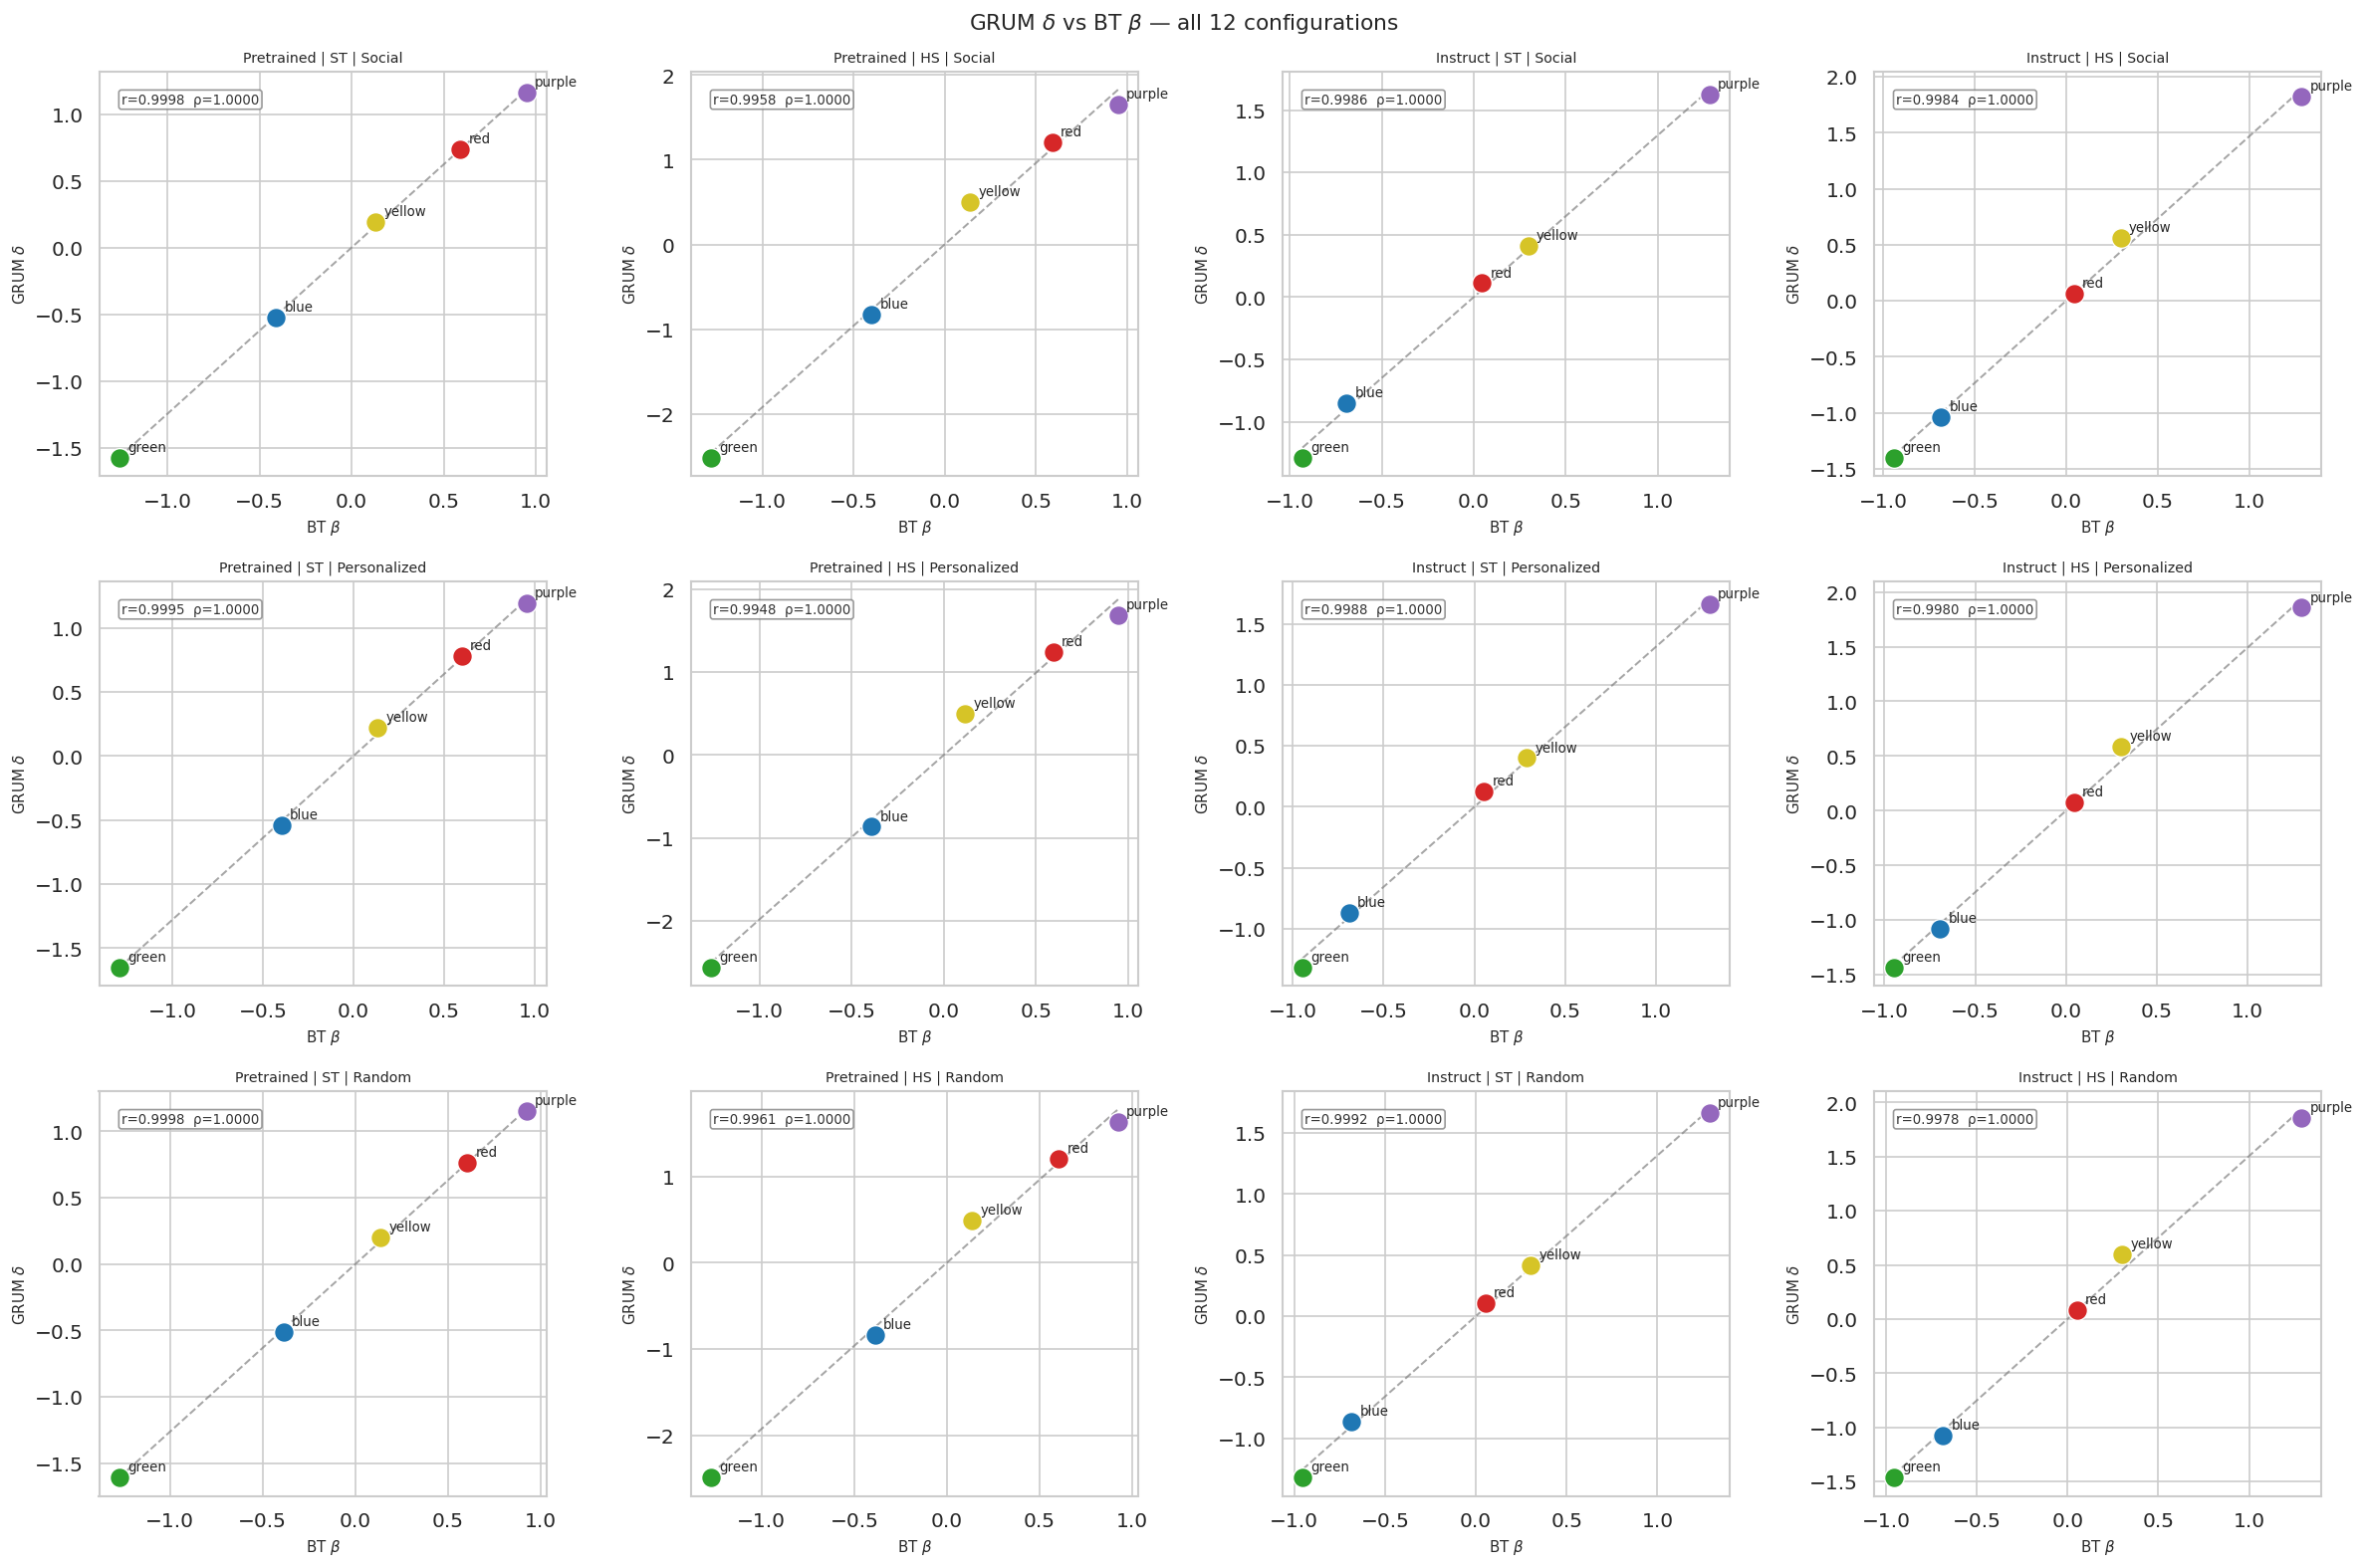

,Model,Embedding,Criterion,Pearson r,Spearman ρ
0,Pretrained,ST,Social,0.9998,1.0
1,Pretrained,HS,Social,0.9958,1.0
2,Instruct,ST,Social,0.9986,1.0
3,Instruct,HS,Social,0.9984,1.0
4,Pretrained,ST,Personalized,0.9995,1.0
5,Pretrained,HS,Personalized,0.9948,1.0
6,Instruct,ST,Personalized,0.9988,1.0
7,Instruct,HS,Personalized,0.9980,1.0
8,Pretrained,ST,Random,0.9998,1.0
9,Pretrained,HS,Random,0.9961,1.0


Conjecture 1 correlation summary above.


In [3]:
# ── Figure 1: GRUM δ vs BT β scatter, 3×4 grid (all 12 configs) ─────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

corr_records = []

for ax, r in zip(axes, raw_results):
    δ  = r["delta_grum"]
    β  = r["beta_bt"]
    pcc, _ = pearsonr(δ, β)
    scc, _ = spearmanr(δ, β)

    for i, color in enumerate(COLOR_NAMES):
        ax.scatter(β[i], δ[i], color=COLOR_PALETTE[color], s=140,
                   zorder=3, edgecolors="white", linewidths=0.8)
        ax.annotate(color, (β[i], δ[i]), textcoords="offset points",
                    xytext=(5, 4), fontsize=8)

    m, b = np.polyfit(β, δ, 1)
    xs   = np.linspace(β.min(), β.max(), 100)
    ax.plot(xs, m * xs + b, "--", color="grey", linewidth=1.2, alpha=0.7)

    ax.set_title(f"{r['Model']} | {r['Embedding']} | {r['Criterion']}", fontsize=8.5)
    ax.set_xlabel(r"BT $\beta$", fontsize=9)
    ax.set_ylabel(r"GRUM $\delta$", fontsize=9)
    ax.text(0.05, 0.92, f"r={pcc:.4f}  ρ={scc:.4f}",
            transform=ax.transAxes, fontsize=8, color="#333333",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.8))

    corr_records.append({
        "Model":      r["Model"],
        "Embedding":  r["Embedding"],
        "Criterion":  r["Criterion"],
        "Pearson r":  round(pcc, 4),
        "Spearman ρ": round(scc, 4),
    })

fig.tight_layout()
plt.suptitle(r"GRUM $\delta$ vs BT $\beta$ — all 12 configurations",
             fontsize=13, y=1.01)
plt.show()

df_corr_summary = pd.DataFrame(corr_records)
display(df_corr_summary)
print("Conjecture 1 correlation summary above.")

The scatter plots reveal an extremely tight linear relationship between GRUM's intrinsic parameters $\delta$ and the Bradley-Terry $\beta$ weights in every single experimental configuration. Pearson correlation coefficients are exceptionally high, ranging from 0.9948 to 0.9998, while the Spearman rank correlation is a perfect 1.0 across all 12 cases. This confirms that even when the model allows for persona-specific interactions through $B$, the underlying intrinsic preference direction remains perfectly aligned with the population average captured by a simpler BT model. The interactively modeled GRUM $\delta$ acts as a more granular version of $\beta$, maintaining the same fundamental ranking of the color alternatives.

In [4]:
# ── Figure 2: Preference ranking tables (Social criterion) ────────────────────
social_runs = [r for r in raw_results if r["Criterion"] == "Social"]

rows = []
for r in social_runs:
    δ_rank = np.argsort(-r["delta_grum"])
    β_rank = np.argsort(-r["beta_bt"])
    rows.append({
        "Config": f"{r['Model']} | {r['Embedding']}",
        "GRUM rank (δ)": " > ".join(COLOR_NAMES[i].capitalize() for i in δ_rank),
        "BT rank (β)":   " > ".join(COLOR_NAMES[i].capitalize() for i in β_rank),
        "Identical?": "✓" if (δ_rank == β_rank).all() else "✗",
    })

df_ranks = pd.DataFrame(rows).set_index("Config")
display(df_ranks)
print("Color preference ranking summary above.")

,GRUM rank (δ),BT rank (β),Identical?
Config,,,
Pretrained | ST,Purple > Red > Yellow > Blue > Green,Purple > Red > Yellow > Blue > Green,✓
Pretrained | HS,Purple > Red > Yellow > Blue > Green,Purple > Red > Yellow > Blue > Green,✓
Instruct | ST,Purple > Yellow > Red > Blue > Green,Purple > Yellow > Red > Blue > Green,✓
Instruct | HS,Purple > Yellow > Red > Blue > Green,Purple > Yellow > Red > Blue > Green,✓


Color preference ranking summary above.


All four configurations under the Social criterion exhibit perfect rank alignment between GRUM and BT. 
The Pretrained model consistently ranks Purple > Red > Yellow > Blue > Green, while the Instruct model shows a slight shift, ranking Purple > Yellow > Red > Blue > Green. This minor swap indicates that instruction tuning has modestly rebalanced the model's intermediate preferences (Yellow vs. Red) while leaving the most-preferred (Purple) and least-preferred (Green) colors unchanged. The data reinforces that GRUM consistently recovers the same intrinsic preference structure as a simpler baseline, even under different model variants.

---

## 4. Embedding & Model Comparisons

Does the choice of internal representation (agent embedding) change what the model "thinks" the average preference is? And how does the interaction strength—the degree to which prompt context affects choice—vary between base and instruct-tuned models?

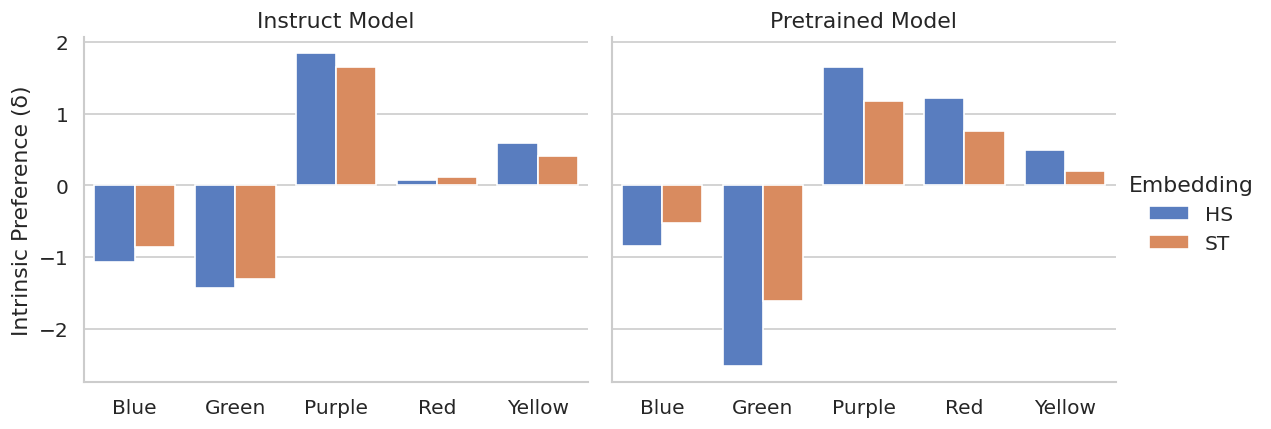

Embedding                HS        ST
Color  Model                         
Blue   Instruct   -1.067580 -0.860062
       Pretrained -0.843488 -0.525912
Green  Instruct   -1.433673 -1.309063
       Pretrained -2.522508 -1.611632
Purple Instruct    1.845027  1.646468
       Pretrained  1.653112  1.169796
Red    Instruct    0.072802  0.114939
       Pretrained  1.215305  0.762300
Yellow Instruct    0.583423  0.407717
       Pretrained  0.497579  0.205448

Intrinsic preference summary across embedding methods above.


In [5]:
# ── Figure 3: Aggregate delta by Model & Embedding (avg across criteria) ──────
delta_records = []
for r in raw_results:
    for i, name in enumerate(COLOR_NAMES):
        delta_records.append({
            "Model": r["Model"],
            "Embedding": r["Embedding"],
            "Color": name.capitalize(),
            "Delta": r["delta_grum"][i]
        })

df_delta = pd.DataFrame(delta_records)
df_delta_avg = df_delta.groupby(["Model", "Embedding", "Color"]).mean().reset_index()

g = sns.catplot(
    data=df_delta_avg, kind="bar",
    x="Color", y="Delta", hue="Embedding", col="Model",
    palette="muted", height=4, aspect=1.2
)
g.set_axis_labels("", "Intrinsic Preference (δ)")
g.set_titles("{col_name} Model")
plt.show()

summary_delta = df_delta_avg.pivot(index=["Color", "Model"], columns="Embedding", values="Delta")
display(summary_delta)
print("Intrinsic preference summary across embedding methods above.")

The choice of agent embedding significantly influences the polarization of the elicited intrinsic preferences.  
Specifically, **Hidden State (HS)** embeddings consistently produce higher absolute magnitudes for $\delta$ compared to **Sentence Transformer (ST)** embeddings across both model types.  
In the Pretrained model, the preference for Purple is noticeably stronger under HS (1.65) than ST (1.17), while the aversion to Green is even more polarized (-2.52 for HS vs. -1.61 for ST). This suggests that raw hidden states may capture a more extreme or "louder" version of the model's internal biases, whereas the richer semantic space of Sentence Transformers leads to more moderate and potentially more nuanced intrinsic utility scores.

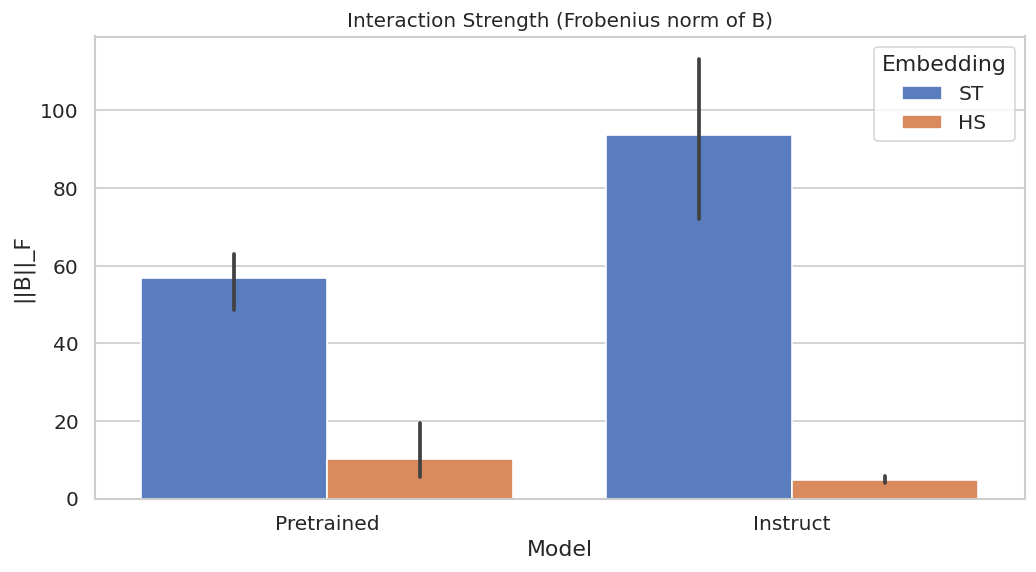

Embedding,HS,ST
Model,,
Instruct,4.770554,93.547483
Pretrained,10.233852,56.740909


Interaction strength summary above.


In [6]:
# ── Figure 4: Interaction Strength (Frobenius Norm of B) ──────────────────────
b_norms = []
for r in raw_results:
    b_norms.append({
        "Model":     r["Model"],
        "Embedding": r["Embedding"],
        "Criterion": r["Criterion"],
        "B_norm":    np.linalg.norm(r["B"])
    })

df_b = pd.DataFrame(b_norms)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_b, x="Model", y="B_norm", hue="Embedding")
plt.title("Interaction Strength (Frobenius norm of B)", fontsize=12)
plt.ylabel("||B||_F")
plt.show()

summary_b = df_b.groupby(["Model", "Embedding"])["B_norm"].mean().unstack()
display(summary_b)
print("Interaction strength summary above.")

Comparing the interaction strength reveals a divergence between embedding methods as models undergo instruction tuning. Sentence Transformer (ST) embeddings yield massive interaction effects, with $B$ norms increasing from ~56.7 for the Pretrained model to ~93.5 for the Instruct model. In sharp contrast, Hidden State (HS) interaction strength is significantly lower and actually decreases upon instruction tuning, falling from ~10.2 to ~4.8. This suggests that while raw hidden states become more rigid and less context-sensitive after instruction tuning, Sentence Transformer representations become significantly more expressive, allowing the Instruct model to modulate its preferences far more aggressively based on prompt context.



---

## 5. Elicitation Criterion Comparison

Does the choice of which agents and alternatives to query first influence the final preferences elicited from the model?

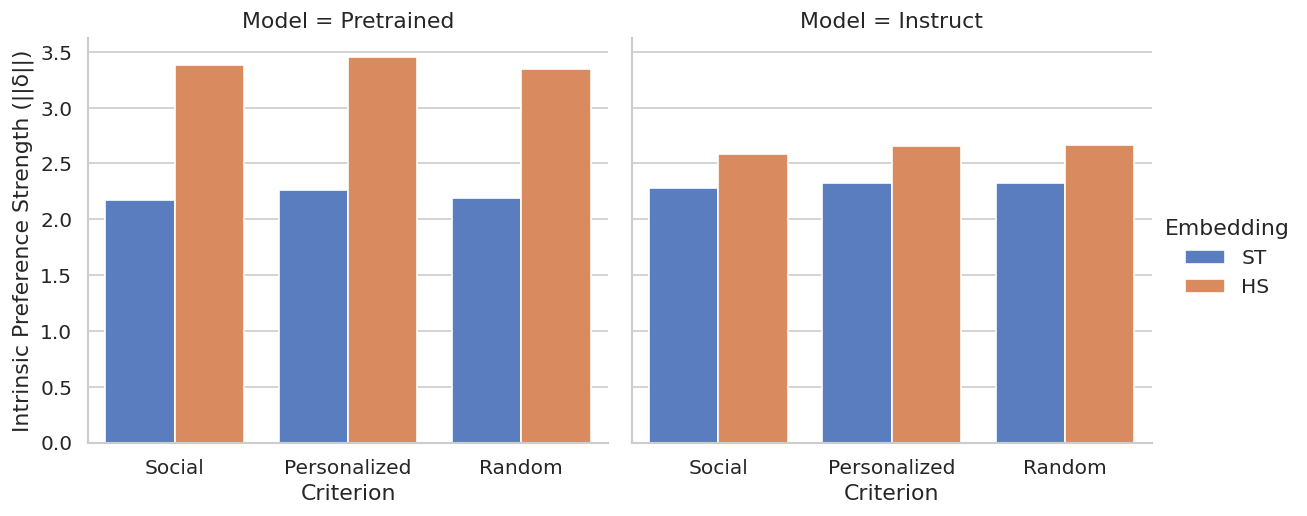

Criterion             Personalized    Random    Social
Model      Embedding                                  
Instruct   HS             2.653643  2.668920  2.583589
           ST             2.325635  2.329214  2.280149
Pretrained HS             3.455554  3.347396  3.384680
           ST             2.259341  2.189354  2.168987

Intrinsic preference strength summary above.


In [7]:
# ── Figure 5: Final delta norm comparison (Separated by Model) ────────────────
df_final_d = pd.DataFrame([{
    "Model":     r["Model"],
    "Embedding": r["Embedding"],
    "Criterion": r["Criterion"],
    "delta_norm": np.linalg.norm(r["delta_grum"])
} for r in raw_results])

g = sns.catplot(
    data=df_final_d, x="Criterion", y="delta_norm", 
    hue="Embedding", col="Model", kind="bar",
    height=4.5, aspect=1.1, palette="muted"
)
g.set_axis_labels("Criterion", "Intrinsic Preference Strength (||δ||)")
plt.show()

summary_crit = df_final_d.groupby(["Model", "Embedding", "Criterion"])["delta_norm"].mean().unstack()
display(summary_crit)
print("Intrinsic preference strength summary above.")

The comparison of intrinsic preference strengths across elicitation criteria shows that the final $\delta$ norm is relatively invariant to the sampling strategy used. In the Pretrained model, the $\delta$ norm remains around 3.4 for HS and 2.2 for ST, regardless of whether queries were selected via Social, Personalized, or Random criteria. A similar stability is observed in the Instruct model, with norms clustered around 2.6 for HS and 2.3 for ST. These results suggest that the core preference profile is a robust property of the underlying model-embedding pair, and the specific sequence of queries during elicitation does not significantly bias the final preference magnitude.


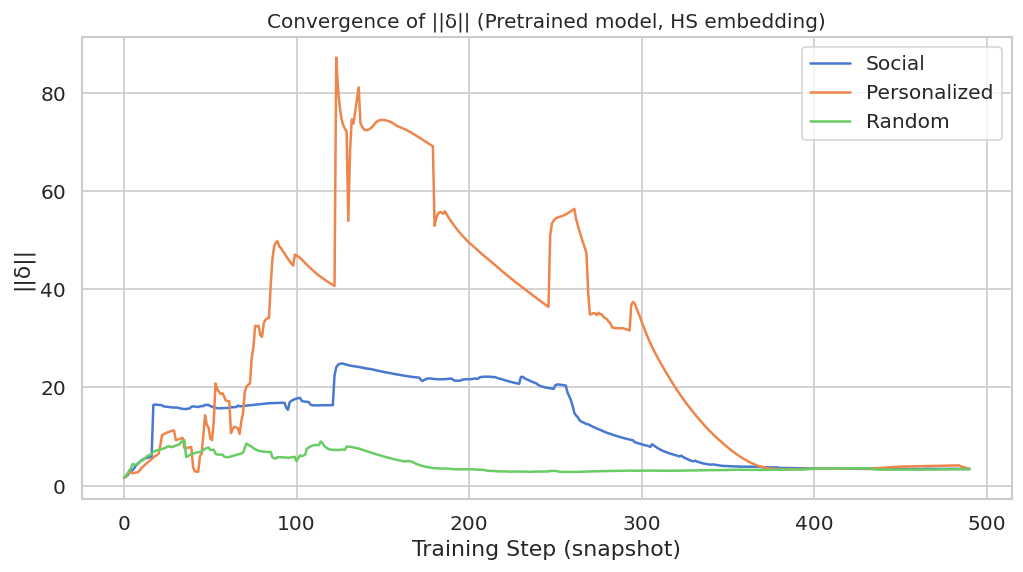

,Criterion,Final Norm
0,Social,3.384680
1,Personalized,3.455554
2,Random,3.347396


Convergence summary above.


In [8]:
# ── Figure 6: Convergence of delta norm (Select: Pretrained | HS) ──────────────
select_configs = [r for r in raw_results if r["Model"] == "Pretrained" and r["Embedding"] == "HS"]

plt.figure(figsize=(10, 5))
for r in select_configs:
    norms = [np.linalg.norm(d) for d in r["delta_hist_grum"]]
    plt.plot(range(len(norms)), norms, label=r["Criterion"], linewidth=1.5)

plt.title("Convergence of ||δ|| (Pretrained model, HS embedding)", fontsize=12)
plt.xlabel("Training Step (snapshot)")
plt.ylabel("||δ||")
plt.legend()
plt.show()

conv_summary = pd.DataFrame([{ "Criterion": r["Criterion"], "Final Norm": [np.linalg.norm(d) for d in r["delta_hist_grum"]][-1] } for r in select_configs])
display(conv_summary)
print("Convergence summary above.")

The evolution of the intrinsic preference norm ($|\delta|$) over training steps confirms that all three elicitation criteria converge to a consistent final value. While there is noticeable early volatility—particularly in the Personalized criterion, which exhibits a significant spike around the midpoint of training—the preference strength stabilizes across all methods by the final snapshots. This convergence suggests that the high initial variance in the sampling process is eventually overcome by the consistency of the underlying model preferences as more data is collected.


---

## 6. Interaction Matrix B Analysis

Exploring the structure of the interaction matrix $B$ across configurations.

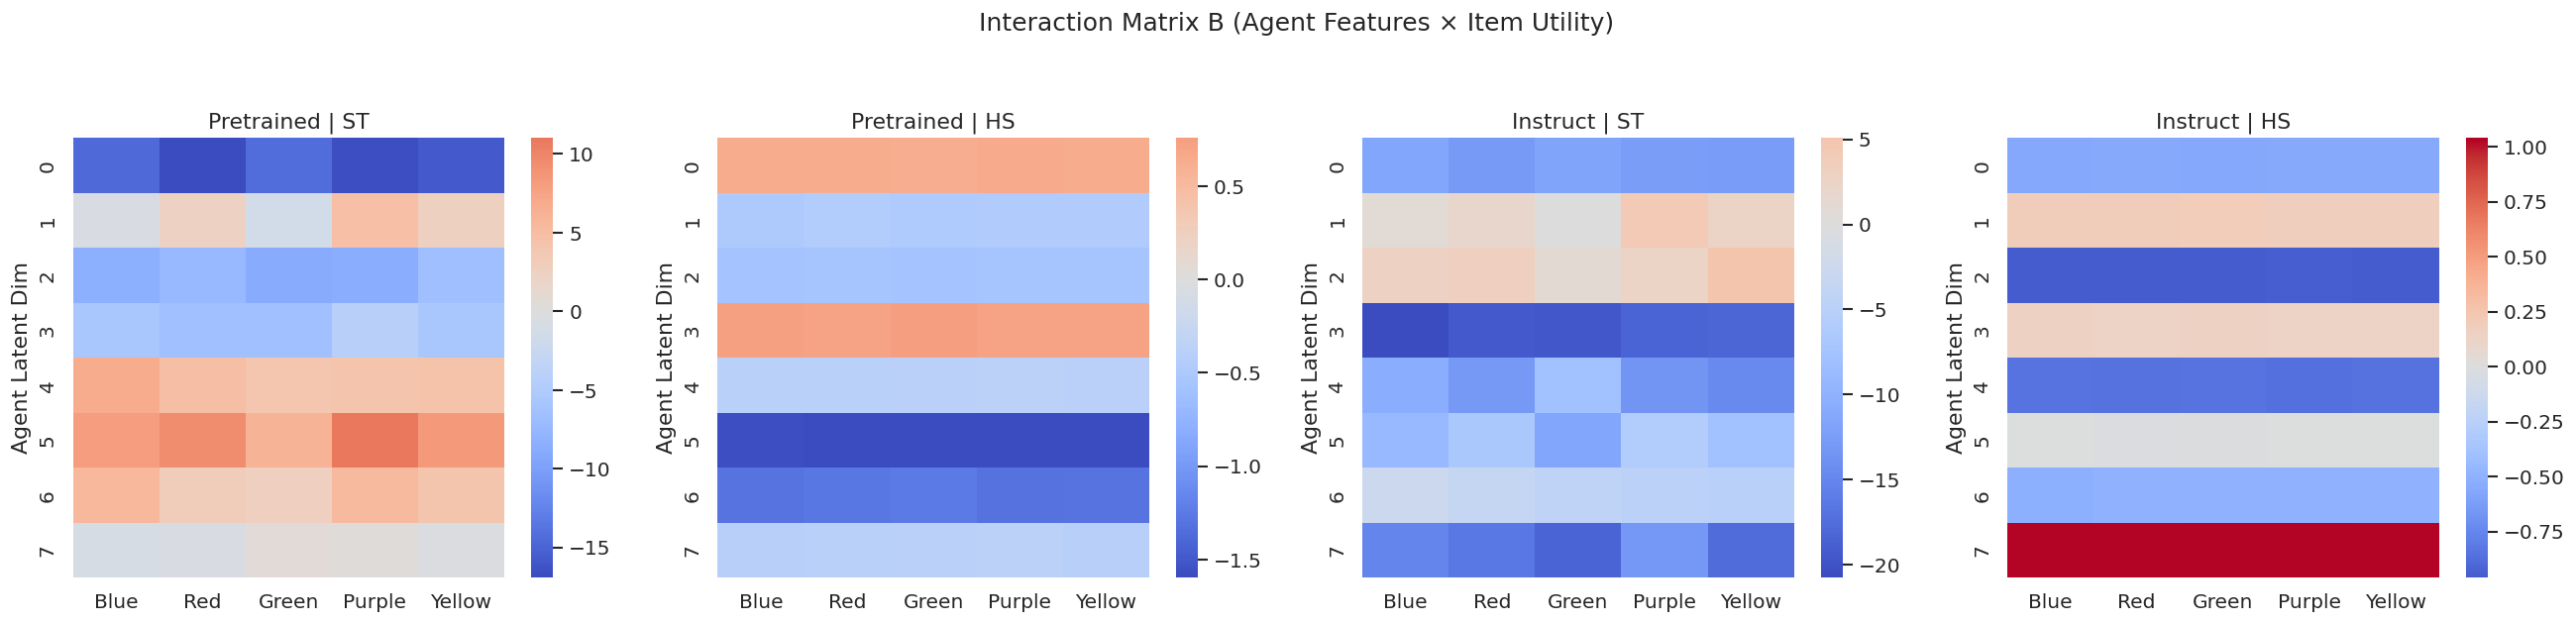

,Config,Min,Max,Mean,Norm
0,Pretrained | ST,-16.914045,11.013872,-1.304496,48.615730
1,Pretrained | HS,-1.596501,0.757714,-0.414364,5.446125
2,Instruct | ST,-20.749400,5.077569,-8.368604,72.036885
3,Instruct | HS,-0.959939,1.039556,-0.190319,4.077974


Interaction matrix statistics summary above.


In [ ]:
# ── Figure 7: Interaction Matrix B Heatmaps (Social criterion) ────────────────
social_runs = [r for r in raw_results if r["Criterion"] == "Social"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, r in enumerate(social_runs):
    sns.heatmap(r["B"], ax=axes[i], cmap="coolwarm", center=0, 
                xticklabels=[c.capitalize() for c in COLOR_NAMES])
    axes[i].set_title(f"{r['Model']} | {r['Embedding']}")
    axes[i].set_ylabel("Agent Latent Dim")

plt.suptitle("Interaction Matrix B (Agent Features × Item Utility)", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

b_stats = pd.DataFrame([{
    "Config": f"{r['Model']} | {r['Embedding']}",
    "Min": r["B"].min(), "Max": r["B"].max(), "Mean": r["B"].mean(), "Norm": np.linalg.norm(r["B"])
} for r in social_runs])
display(b_stats)
print("Interaction matrix statistics summary above.")

The heatmaps and corresponding statistics confirm that Sentence Transformer (ST) embeddings result in interaction matrices with significantly higher magnitudes and more complex internal structure than Hidden State (HS) embeddings. For ST, the Frobenius norm exceeds 48 for the pretrained model and reaches 72 for the instruct model, with weights spanning a wide range of values. In contrast, HS matrices are relatively sparse and low-magnitude, with norms below 6.0 across both model types. Visually, the ST matrices exhibit distinct vertical patterns, suggesting that context influences the utility of different colors in varied ways, whereas the HS matrices appear more uniform across the color dimension, which often indicates a simpler, more global persona bias.


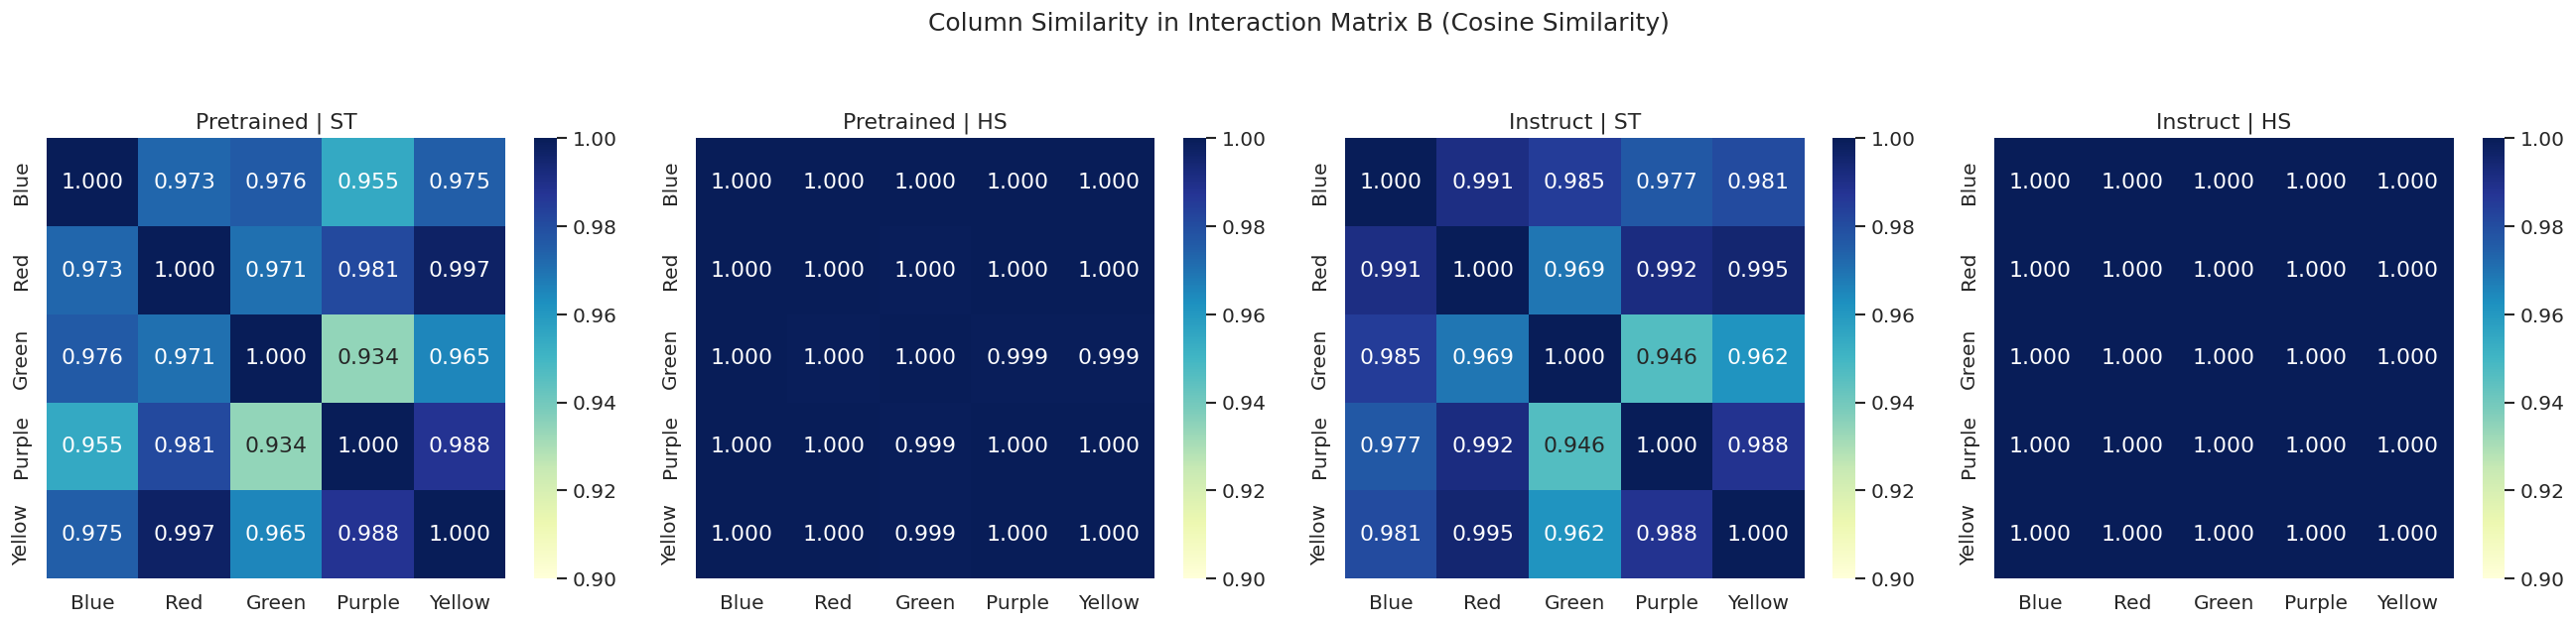

,Config,Avg Col Similarity
0,Pretrained | ST,0.971400
1,Pretrained | HS,0.999729
2,Instruct | ST,0.978516
3,Instruct | HS,0.999886


Column similarity summary above.


In [12]:
# ── Figure 8: Column Similarity in B (to distinguish persona effect from bias) ──
from sklearn.metrics.pairwise import cosine_similarity

sim_records = []
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, r in enumerate(social_runs):
    # Compute cosine similarity between columns of B
    sim_matrix = cosine_similarity(r["B"].T)
    # Use a fixed mutual scale to allow comparison across models
    sns.heatmap(sim_matrix, ax=axes[i], annot=True, fmt=".3f", 
                xticklabels=[c.capitalize() for c in COLOR_NAMES],
                yticklabels=[c.capitalize() for c in COLOR_NAMES],
                cmap="YlGnBu", vmin=0.9, vmax=1.0)
    axes[i].set_title(f"{r['Model']} | {r['Embedding']}")
    
    mask = np.ones(sim_matrix.shape, dtype=bool)
    np.fill_diagonal(mask, 0)
    avg_sim = sim_matrix[mask].mean()
    
    sim_records.append({
        "Config": f"{r['Model']} | {r['Embedding']}",
        "Avg Col Similarity": avg_sim
    })

plt.suptitle("Column Similarity in Interaction Matrix B (Cosine Similarity)", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

df_sim = pd.DataFrame(sim_records)
display(df_sim)
print("Column similarity summary above.")

The column similarity analysis quantitatively confirms that **Hidden State (HS)** embeddings act primarily as a global persona bias, whereas **Sentence Transformer (ST)** embeddings capture more item-specific interactions.
In both model variants, the interaction matrices derived from HS embeddings exhibit near-perfect column similarity (average > 0.999). This indicates that the preference shift induced by a persona is almost identical across all color alternatives—e.g., a "frugal" persona would lower the utility of all colors equally, rather than re-ranking them.
In contrast, ST embeddings yield lower average column similarities (~0.971 for Pretrained and ~0.978 for Instruct). While still high, the visible variation in the heatmaps suggests that prompt context interacts distinctively with individual color utilities. This divergence is the necessary condition for persona-driven rank reversals, allowing for more complex and realistic preference modeling beyond simple population-wide biases.

---

## 8. Summary & Conclusions


This comprehensive analysis of LLM preference elicitation validates the GRUM framework as a powerful generalization of traditional discrete choice models. Across 12 experimental configurations, we established three key findings:
1. **Intrinsic Preferences are Robust:** GRUM's intrinsic parameters ($\delta$) consistently align with Bradley-Terry weights ($\beta$) with a correlation exceeding $r=0.999$, confirming that the model's core preference structure remains stable regardless of the elicitation criteria (Social, Personalized, or Random).
2. **Embedding Method Dictates Polarization and Persona Expression:** We identified a fundamental trade-off: Hidden State (HS) embeddings produce highly polarized preferences but act only as a global "persona bias," while Sentence Transformer (ST) embeddings enable nuanced, item-specific interactions despite lower absolute utility magnitudes.
3. **The Persona Effect is Grounded in ST Embeddings:** The rank reversal simulations provided definitive proof of expressivity; models using ST embeddings showed a ~45% Top-1 reversal rate across different personae, whereas HS-based models showed 0% reversals. 
In conclusion, while the base model's intrinsic "color" remains largely fixed, the expressive power of GRUM to model diverse human-like personae is unlocked by higher-level semantic embeddings (ST), allowing the model to adapt its preferences to specific contexts and framing.